In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('sensor_data.csv')
df.head()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.18,27.2720,426.0,721.25,0.004793,1
1,23.15,27.2675,429.5,714.00,0.004783,1
2,23.15,27.2450,426.0,713.50,0.004779,1
3,23.15,27.2000,426.0,708.25,0.004772,1
4,23.10,27.2000,426.0,704.50,0.004757,1


In [3]:
df.shape

(8143, 6)

In [4]:
df.describe()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
std,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
max,23.180000,39.117500,1546.333333,2028.500000,0.006476,1.000000


In [5]:
df['Occupancy'].value_counts()

0    6414
1    1729
Name: Occupancy, dtype: int64

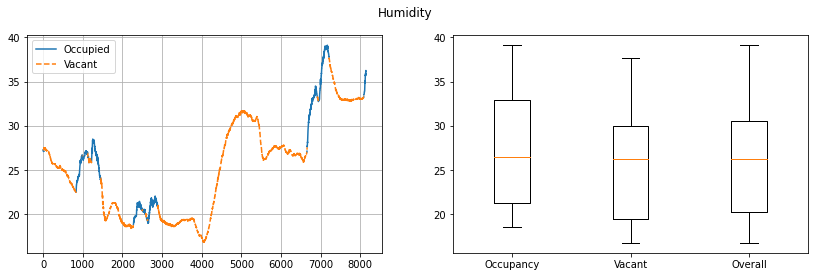

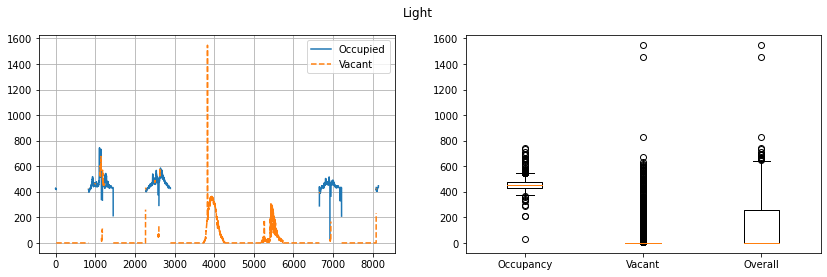

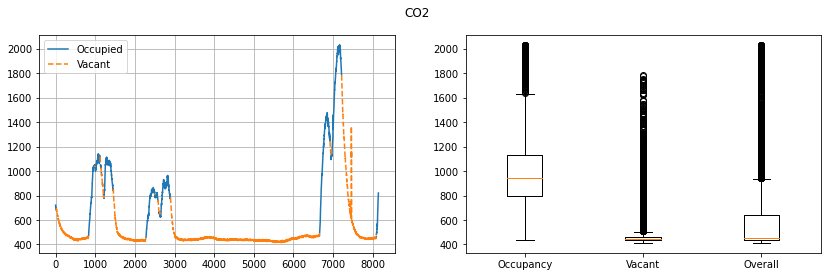

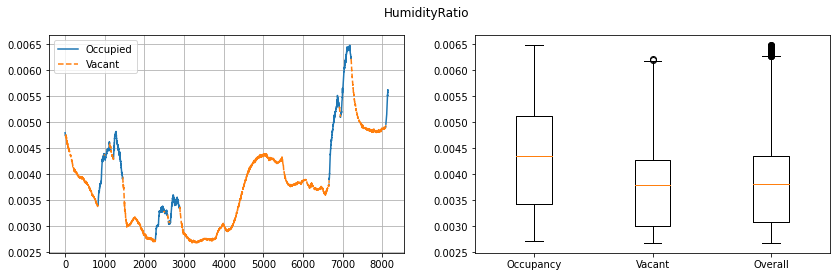

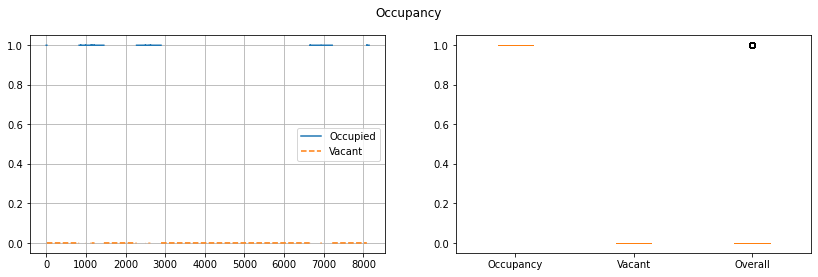

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def occupancy_plot(df, cat):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
    
    fig.suptitle(cat)
    ax1.plot(np.where(df.Occupancy==1, df[cat], None), label='Occupied')
    ax1.plot(np.where(df.Occupancy==0, df[cat], None), label='Vacant', ls='--')
    ax1.grid()
    ax1.legend()
    
    ax2.boxplot([df[cat][df.Occupancy==1], df[cat][df.Occupancy==0], df[cat]])
    ax2.set_xticklabels(['Occupancy', 'Vacant', 'Overall'])


for i in range(1, 6):
    occupancy_plot(df, df.columns[i])


In [7]:
df2 = df
df2 = df2[np.abs(df2.Temperature - df2.Temperature.mean()) <= 3*df2.Temperature.std()]
print("1. Removing the Outliers on 'Temperature' has reduced the data size from {} to {}.".format(len(df), len(df2)))
print("\n")
df = df2[np.abs(df2.Light - df2.Light.mean()) <= 3*df2.Light.std()]
print("2. Removing the Outliers on 'Light' has reduced the data size from {} to {}.".format(len(df2), len(df)))
print("\n")
df2 = df[np.abs(df.CO2 - df.CO2.mean()) <= 3*df2.CO2.std()]
print("3. Removing the Outliers on 'CO2' has reduced the data size from {} to {}.".format(len(df), len(df2)))
print("\n")

1. Removing the Outliers on 'Temperature' has reduced the data size from 8143 to 8143.


2. Removing the Outliers on 'Light' has reduced the data size from 8143 to 8137.


3. Removing the Outliers on 'CO2' has reduced the data size from 8137 to 7926.




In [8]:
df2.describe()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,7926.000000,7926.000000,7926.000000,7926.000000,7926.000000,7926.000000
mean,20.580918,25.403866,111.569184,572.861650,0.003799,0.193793
std,1.003361,5.215692,189.112536,239.738295,0.000767,0.395293
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,19.700000,20.037500,0.000000,439.000000,0.003064,0.000000
50%,20.390000,26.100000,0.000000,452.500000,0.003789,0.000000
75%,21.290000,29.716875,147.875000,589.687500,0.004326,0.000000
max,23.180000,37.000000,696.500000,1545.666667,0.005954,1.000000


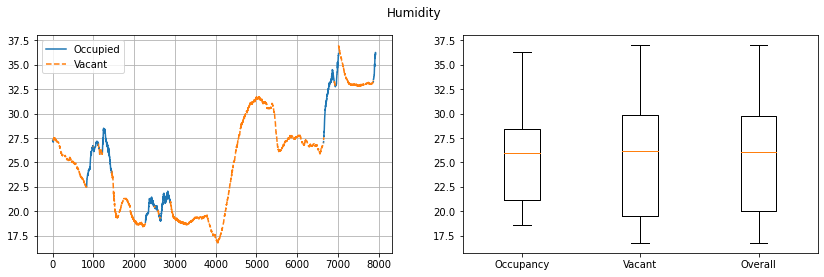

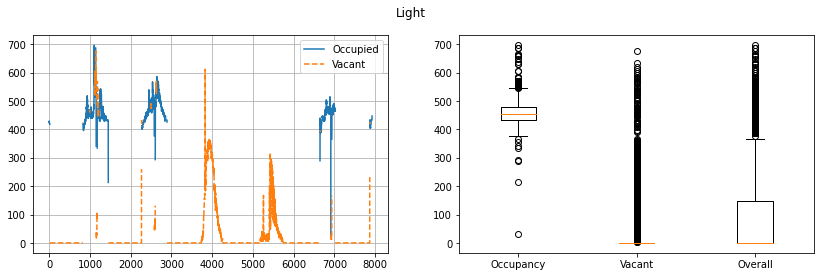

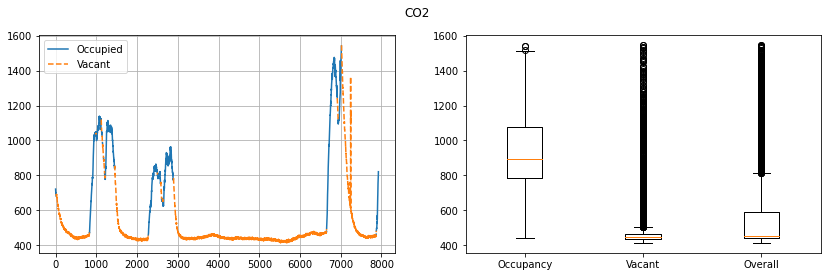

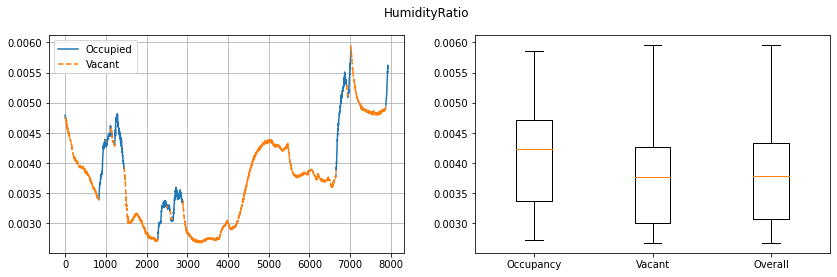

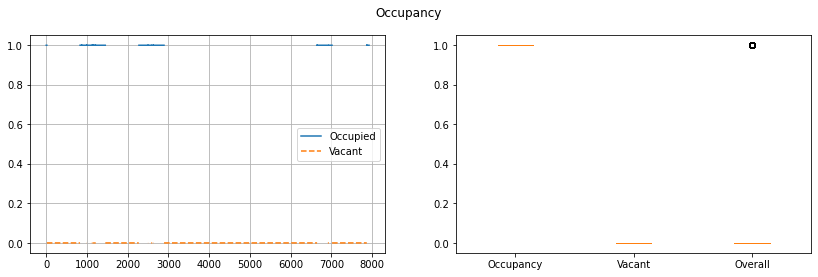

In [9]:
for i in range(1, 6):
    occupancy_plot(df2, df2.columns[i])

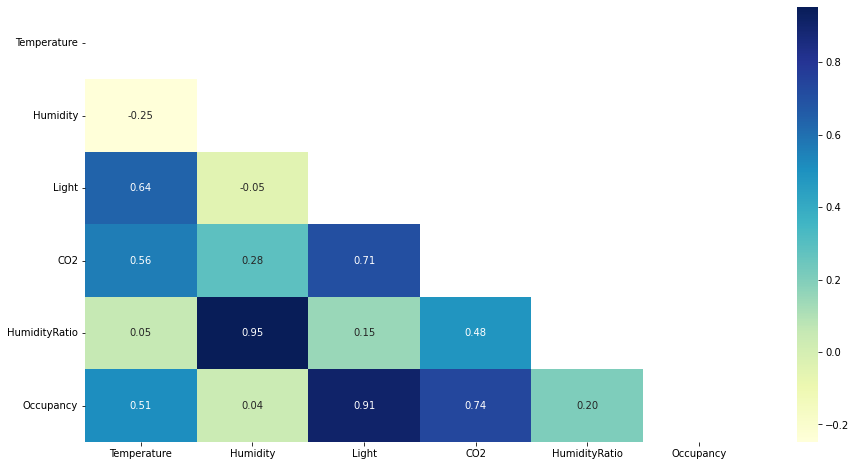

In [10]:
import seaborn as sns

mask = np.triu(np.ones_like(df2.corr()))
plt.figure(figsize = (15,8))
sns.heatmap(df2.corr(),annot=True, fmt="1.2f", mask=mask, cmap="YlGnBu")
plt.yticks(rotation=0)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

X, Y = df2.iloc[:,1:-1], df2.iloc[:,-1]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=0)

# Create a dataframe that used to store data from confusion matrix and accuracy 
result = pd.DataFrame(columns=['Classifier','True Negative', 'False Postive', 'False Negative', 'True Positive', 'Classifier Accuracy'])


def accuracy_vis(xtest, ytest, ypred, predit_proba):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
    # Confusion Matrix Visulation
    cm = confusion_matrix(ytest, ypred)
    x_axis_labels = ['Actual Postive', 'Actual Negative']
    y_axis_labels = ['Predicted Postive', 'Predicted Negative']
    sns.heatmap(cm, fmt=".0f", annot=True, linewidths=.5, ax=ax1, 
                cmap="YlGnBu", xticklabels=x_axis_labels)
    ax1.set_yticklabels(y_axis_labels, rotation=0, ha='right')
    
    # ROC Curve Visulation
    logit_roc_auc = roc_auc_score(ytest, ypred)
    fpr, tpr, thresholds = roc_curve(ytest, predit_proba[:,1])
    ax2.plot(fpr, tpr, label='Logistic Regression (area = {})'.format(round(logit_roc_auc,6)))
    ax2.plot([0, 1], [0, 1],'r--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend()
    plt.show()
    return(confusion_matrix(Y_test, Y_pred).ravel())
        

Accuracy of Logistic Regression Classifier on test set: 98.738648%


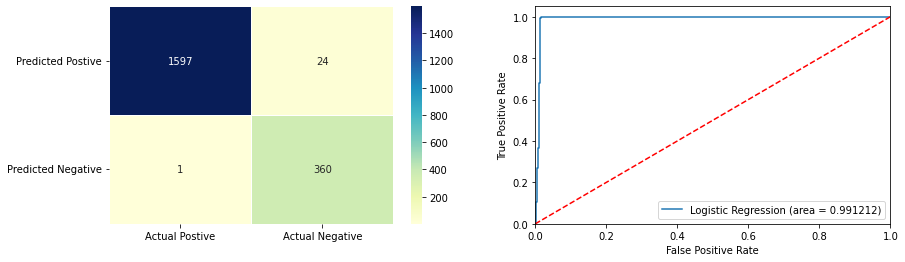

In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, Y_train)
Y_pred, lr_score, predit_proba = lr.predict(X_test), lr.score(X_test, Y_test), lr.predict_proba(X_test)
print('Accuracy of Logistic Regression Classifier on test set: {:.6f}%'.format(lr_score*100))
tn, fp, fn, tp = accuracy_vis(X_test, Y_test, Y_pred, predit_proba)
result.loc['LR'] = ['Logistic Regression', tn, fp, fn, tp, round(lr_score*100, 6)]

Accuracy of K Nearest Neighbors Classifier on test set: 98.789102%


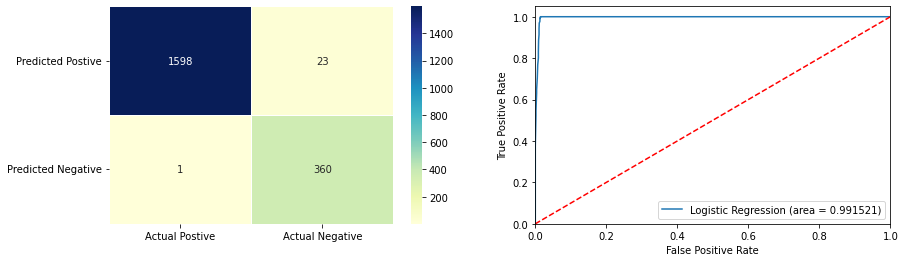

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=int(np.sqrt(len(X_train))))
knn.fit(X_train, Y_train)
Y_pred, knn_score, predit_proba  = knn.predict(X_test), knn.score(X_test, Y_test), knn.predict_proba(X_test)
print('Accuracy of K Nearest Neighbors Classifier on test set: {:.6f}%'.format(knn_score*100))
tn, fp, fn, tp = accuracy_vis(X_test, Y_test, Y_pred, predit_proba)
result.loc['KNN'] = ['K Nearest Neighbors', tn, fp, fn, tp, round(knn_score*100, 6)]

Accuracy of Support Vector Machine Classifier on test set: 98.738648%


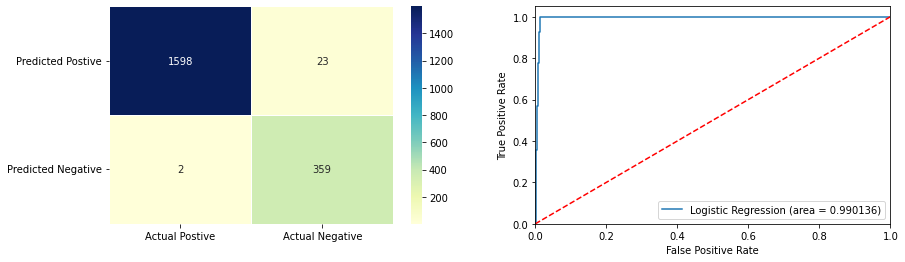

In [14]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, Y_train)
Y_pred, svm_score, predit_proba = svm.predict(X_test), svm.score(X_test, Y_test), svm.predict_proba(X_test)
print('Accuracy of Support Vector Machine Classifier on test set: {:.6f}%'.format(svm_score*100))
tn, fp, fn, tp = accuracy_vis(X_test, Y_test, Y_pred, predit_proba)
result.loc['SVM'] = ['Support Vector Machine', tn, fp, fn, tp, round(svm_score*100, 6)]

Accuracy of Decision Tree Classifier on test set: 98.688194%


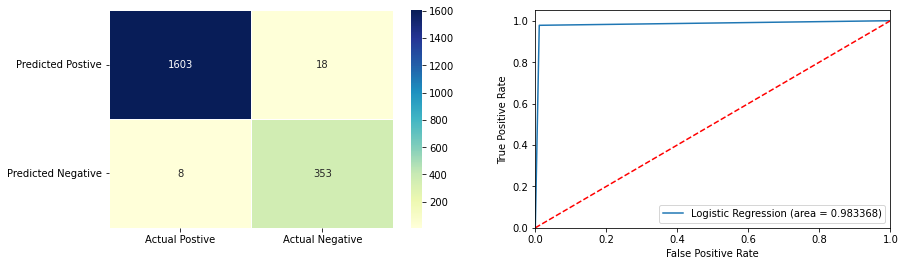

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, Y_train)
Y_pred, dt_score, predit_proba = dt.predict(X_test), dt.score(X_test, Y_test), dt.predict_proba(X_test)
print('Accuracy of Decision Tree Classifier on test set: {:.6f}%'.format(dt_score*100))
tn, fp, fn, tp = accuracy_vis(X_test, Y_test, Y_pred, predit_proba)
result.loc['DT'] = ['Decision Tree', tn, fp, fn, tp, round(dt_score*100, 6)]

Accuracy of Random Forest Classifier on test set: 99.192735%


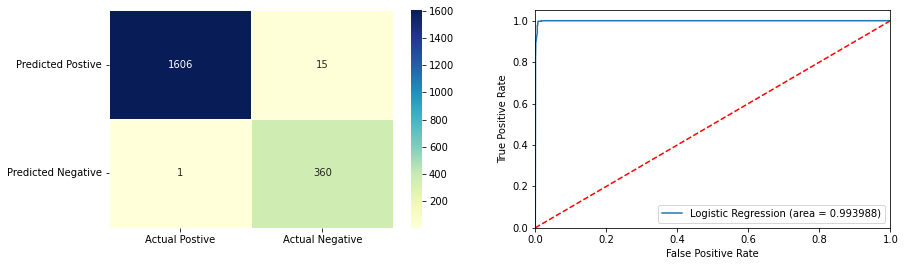

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, Y_train)
Y_pred, rf_score, predit_proba = rf.predict(X_test), rf.score(X_test, Y_test), rf.predict_proba(X_test)
print('Accuracy of Random Forest Classifier on test set: {:.6f}%'.format(rf_score*100))
tn, fp, fn, tp = accuracy_vis(X_test, Y_test, Y_pred, predit_proba)
result.loc['RF'] = ['Random Forest', tn, fp, fn, tp, round(rf_score*100, 6)]

In [17]:
result.sort_values('Classifier Accuracy', ascending=False)

,Classifier,True Negative,False Postive,False Negative,True Positive,Classifier Accuracy
RF,Random Forest,1606,15,1,360,99.192735
KNN,K Nearest Neighbors,1598,23,1,360,98.789102
LR,Logistic Regression,1597,24,1,360,98.738648
SVM,Support Vector Machine,1598,23,2,359,98.738648
DT,Decision Tree,1603,18,8,353,98.688194
